In [1]:
import pandas as pd

# טעינת הדאטה ישירות מהמאגר של UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00471/Data_for_UCI_named.csv"
df = pd.read_csv(url)

print("Data shape:", df.shape)
display(df.head())

# הכנת הנתונים:
# נפריד בין הפיצ'רים למטרות (Targets)
X = df.drop(columns=['stab', 'stabf'])

# משתנה המטרה לרגרסיה (רציף)
y_regression = df['stab']

# משתנה המטרה לסיווג (קטגורי)
# נהפוך את stable ל-1 ואת unstable ל-0
y_classification = (df['stabf'] == 'stable').astype(int)

print("\nFeatures (X) preview:")
display(X.head())


Data shape: (10000, 14)


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Features (X) preview:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


### 1.1 Regression Error Analysis: Residual Analysis

לפני שניגש לניתוח השגיאות, נגדיר את אסטרטגיית ה-Cross-Validation כמבוקש. בחרנו ב-K-Fold עם $k=5$. בהינתן סט נתונים של 10,000 רשומות, 5 קיפולים מספקים איזון אופטימלי במסגרת ה-Bias-Variance Trade-off: כל סט אימון יכיל 8,000 רשומות (מספיק כדי לאמן מודלים מורכבים ביציבות), זמן הריצה יהיה סביר, וסט הבדיקה (2,000 רשומות בכל איטרציה) גדול דיו כדי לספק הערכת שגיאה אמינה.

כדי לנתח את השאריות, נאמן מודל בסיס (Baseline) מסוג רגרסיה ליניארית ונייצר תחזיות. המטרה היא לבחון:
* האם השאריות ממורכזות סביב אפס.
* האם קיימות תבניות שיטתיות בשגיאה.
* האם יש עדות לשונות לא קבועה (Heteroscedasticity).


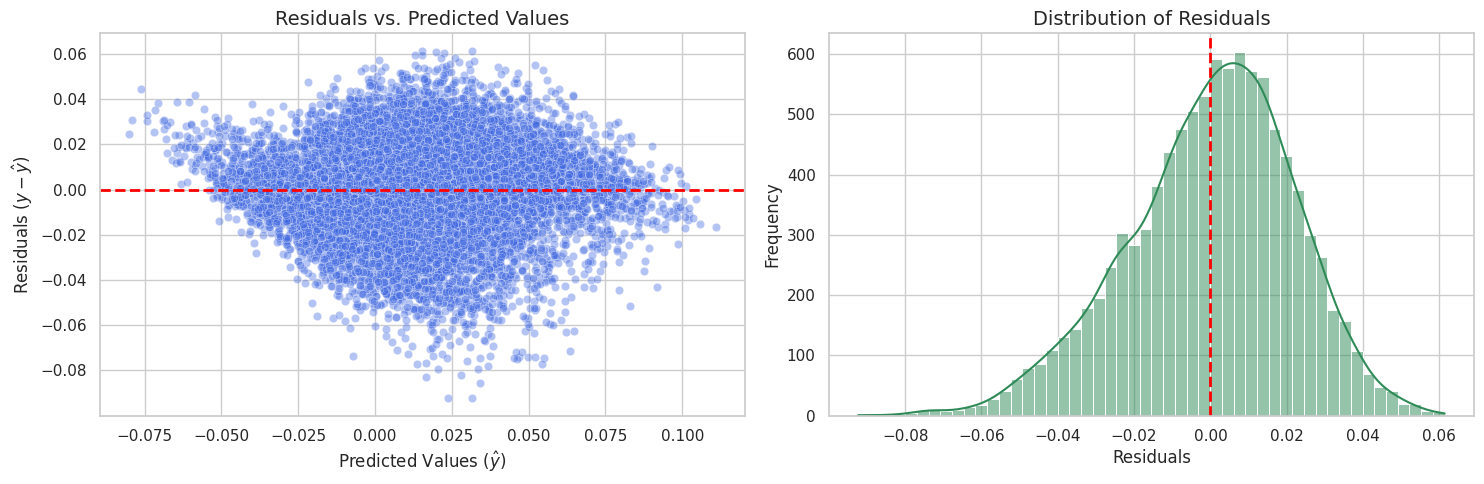

Mean of residuals: -0.00000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# הגדרת K-Fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# יצירת מודל בייסליין ליניארי וקבלת תחזיות באמצעות CV
lr_model = LinearRegression()
y_pred = cross_val_predict(lr_model, X, y_regression, cv=kf)

# חישוב השאריות לפי הנוסחה
residuals = y_regression - y_pred

# הגדרת סגנון לגרפים
sns.set_theme(style="whitegrid")

# שרטוט הגרפים - סעיף 1.1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. שאריות מול ערכים חזויים
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[0], color='royalblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=14)
axes[0].set_xlabel(r'Predicted Values ($\hat{y}$)', fontsize=12)
axes[0].set_ylabel(r'Residuals ($y - \hat{y}$)', fontsize=12)

# 2. התפלגות השאריות (היסטוגרמה)
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].set_xlabel('Residuals', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Mean of residuals: {np.mean(residuals):.5f}")


### מסקנות ביניים: סעיף 1.1 (ניתוח שאריות)
* **מרכוז והטיה:** התפלגות השאריות נראית כפעמון סימטרי (התפלגות נורמלית) הממורכז סביב האפס. המשמעות היא שלמודל הרגרסיה **אין הטיה שיטתית (Systematic Bias)**.
* **פיזור השגיאות:** בגרף השאריות מול הערכים החזויים, ניתן להבחין בתופעה של **הטרוסקדסטיות (Heteroscedasticity)** – פיזור השגיאות אינו קבוע ורוחב ה"ענן" משתנה. הדבר מרמז על קיומם של קשרים לא ליניאריים בעולם האמיתי, שהמודל הפשוט מפספס.

### 1.2 Error as a Function of Features

בסעיף זה נבחן את הקשר בין פרמטרי המערכת השונים לבין גודל השגיאה. כיוון שמדובר בסימולציה של רשת חשמל, בחרנו להתמקד בפיצ'רים המייצגים את זמני התגובה של הצמתים השונים ברשת (tau1, tau2, tau3, tau4).

שרטוט ערכי הפיצ'רים אל מול השאריות (Residuals) והשגיאות המוחלטות (Absolute Errors) יעזור לנו:
* לזהות קשרים לא-ליניאריים שמודל הרגרסיה הליניארית הפשוט מפספס.
* לחפש אזורי פעולה ספציפיים ברשת שבהם השגיאה גדלה בצורה משמעותית.

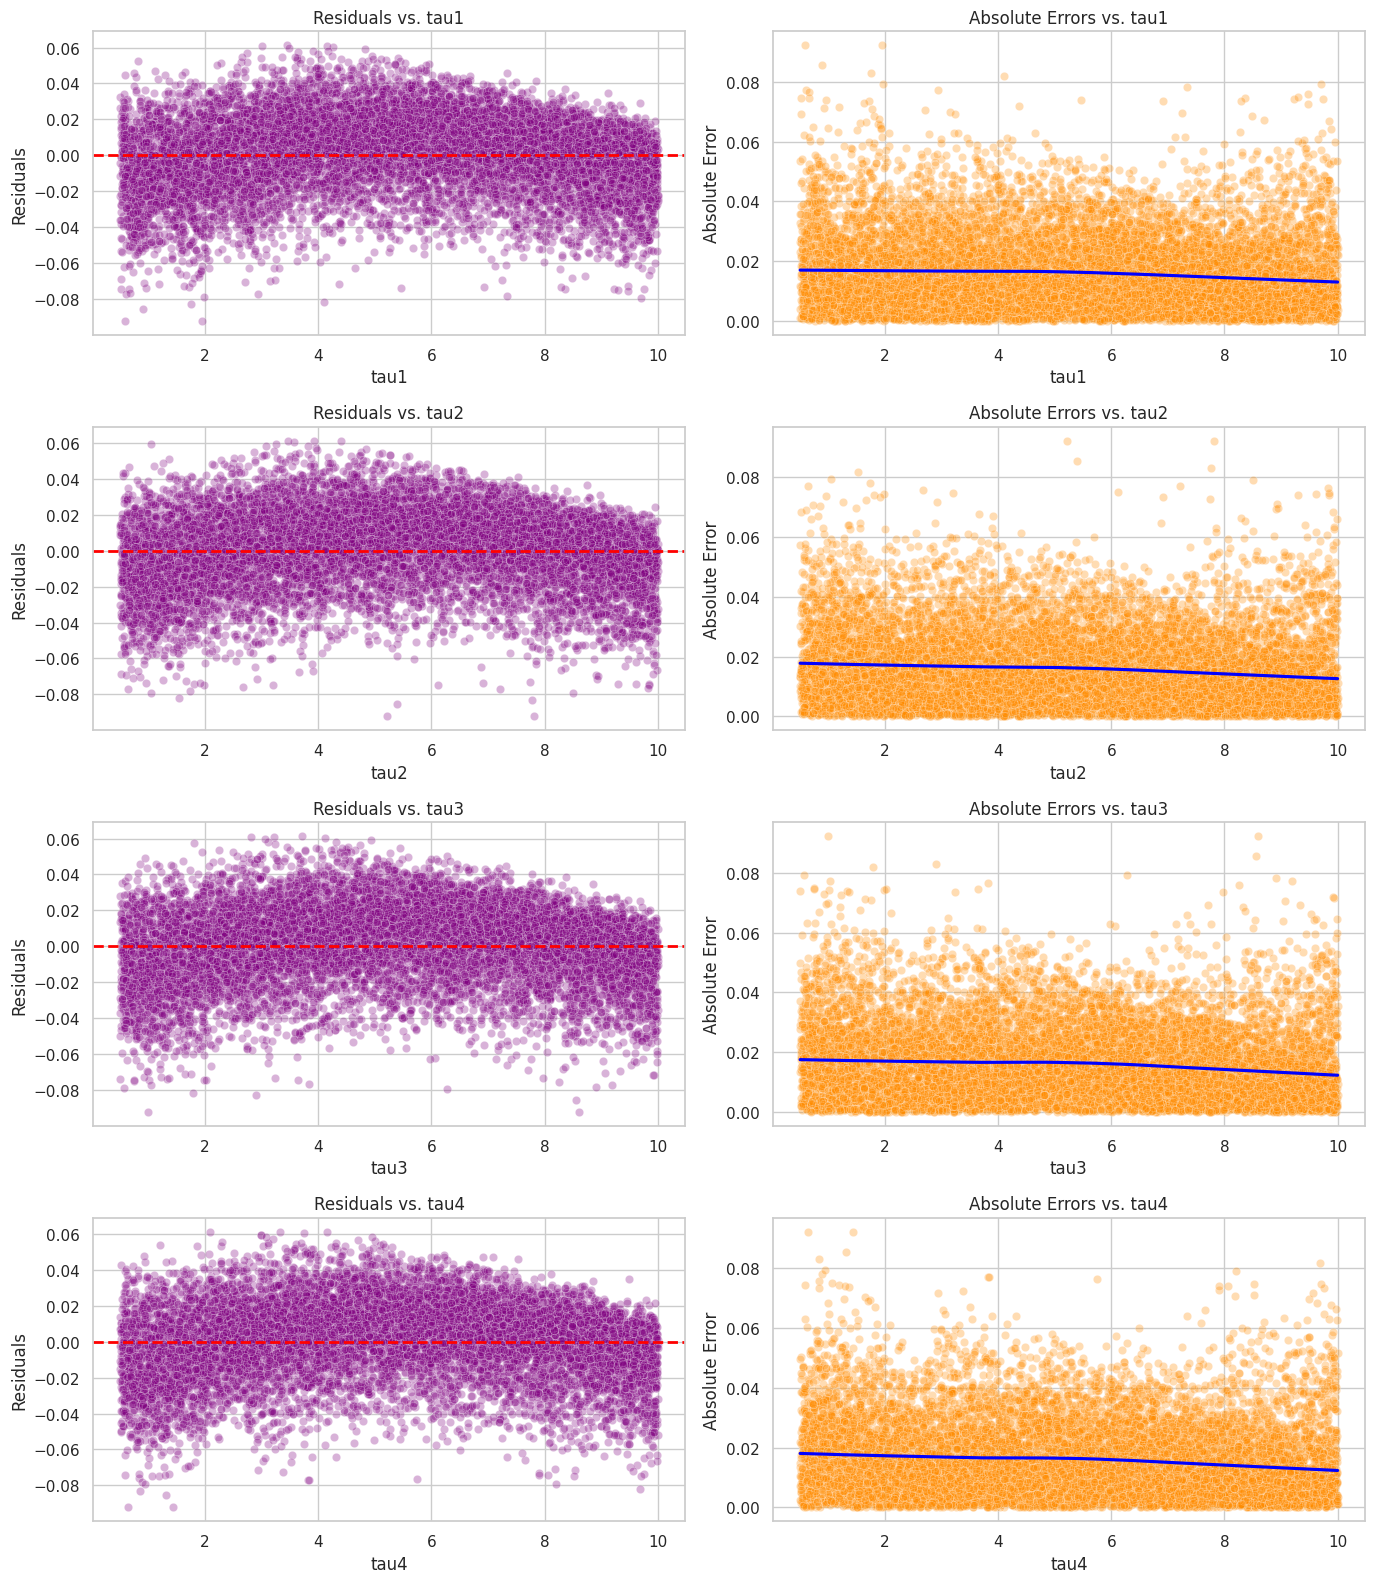

In [ ]:
# סעיף 1.2: ניקח את 4 הפיצ'רים הראשונים (זמני התגובה של הצמתים - tau) לצורך הניתוח
features_to_plot = ['tau1', 'tau2', 'tau3', 'tau4']
absolute_errors = np.abs(residuals)

# יצירת מטריצת גרפים - 4 שורות, 2 עמודות
fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(14, 4 * len(features_to_plot)))

for i, feature in enumerate(features_to_plot):
    # עמודה 1: פיצ'רים מול שאריות
    sns.scatterplot(x=X[feature], y=residuals, alpha=0.3, ax=axes[i, 0], color='purple')
    axes[i, 0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'Residuals vs. {feature}', fontsize=12)
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Residuals')

    # עמודה 2: פיצ'רים מול שגיאות מוחלטות
    sns.scatterplot(x=X[feature], y=absolute_errors, alpha=0.3, ax=axes[i, 1], color='darkorange')
    # נוסיף קו מגמה (LOWESS) כדי להבליט תבניות לא ליניאריות
    sns.regplot(x=X[feature], y=absolute_errors, scatter=False, ax=axes[i, 1], color='blue', lowess=True)
    axes[i, 1].set_title(f'Absolute Errors vs. {feature}', fontsize=12)
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()


### מסקנות ביניים: סעיף 1.2 (השגיאה כפונקציה של הפיצ'רים)
מניתוח השגיאה המוחלטת אל מול זמני התגובה של הרשת (משתני ה-`tau`), זיהינו קשר לא-ליניארי.
המודל הליניארי מתקשה וטועה הרבה יותר באזורי הפעולה שבהם זמני התגובה קצרים. לעומת זאת, ככל שזמן התגובה מתארך והרשת מגיבה לאט יותר, השגיאה המוחלטת הולכת ויורדת.

### 1.3 ניתוח שגיאות קיצון (Analysis of Extreme Errors) 🔍

בסעיף זה נזהה וננתח את 5% התצפיות בעלות השגיאה המוחלטת הגדולה ביותר (מעל האחוזון ה-95).
המטרה היא להבין האם שגיאות אלו נובעות מ:
* **בעיות איכות נתונים:** ערכים חסרים או שגויים בתוך המאגר 📊.
* **מגבלות המודל:** חוסר יכולת של הרגרסיה הליניארית לתפוס קשרים מורכבים 🤖.
* **מקרים נדירים:** מצבי קיצון ברשת החשמל שהם פשוט קשים לחיזוי 🦄.

נשווה את ממוצעי הפיצ'רים של מקרי הקיצון לעומת שאר הנתונים כדי לראות אם יש משתנה ספציפי שגורם למודל "להשתגע".


In [ ]:
# חישוב סף השגיאה עבור ה-5% העליונים (אחוזון 95)
threshold_95 = np.percentile(absolute_errors, 95)

# יצירת מסנן למקרי הקיצון
extreme_errors_mask = absolute_errors >= threshold_95

# הפרדת הנתונים לשתי קבוצות
extreme_data = X[extreme_errors_mask]
normal_data = X[~extreme_errors_mask]

print(f"סף השגיאה (Threshold) עבור ה-5% העליונים: {threshold_95:.4f}")
print(f"מספר מקרי הקיצון שזוהו: {len(extreme_data)} מתוך {len(X)}\n")

# יצירת טבלת השוואה בין הממוצעים
comparison_df = pd.DataFrame({
    'Normal Cases Mean': normal_data.mean(),
    'Extreme Cases Mean': extreme_data.mean()
})

# חישוב אחוז השינוי בצורה תקינה ללא שגיאות הזחה
comparison_df['Difference (%)'] = (
    (comparison_df['Extreme Cases Mean'] - comparison_df['Normal Cases Mean'])
    / comparison_df['Normal Cases Mean']
) * 100

print("=== השוואת מאפיינים: מקרים רגילים מול מקרי קיצון ===")
display(comparison_df.round(2))

סף השגיאה (Threshold) עבור ה-5% העליונים: 0.0433
מספר מקרי הקיצון שזוהו: 500 מתוך 10000

=== השוואת מאפיינים: מקרים רגילים מול מקרי קיצון ===


,Normal Cases Mean,Extreme Cases Mean,Difference (%)
tau1,5.28,4.61,-12.80
tau2,5.28,4.70,-11.02
tau3,5.29,4.50,-14.95
tau4,5.28,4.64,-12.11
p1,3.75,3.74,-0.25
p2,-1.25,-1.23,-2.03
p3,-1.25,-1.27,1.53
p4,-1.25,-1.25,-0.25
g1,0.52,0.63,21.87
g2,0.52,0.62,18.25


### מסקנות ביניים: סעיף 1.3 (ניתוח שגיאות קיצון)
מניתוח ה-5% של התחזיות בעלות השגיאה הגדולה ביותר, עולה כי מקרים אלו מתאפיינים בשילוב של זמני תגובה מהירים (tau נמוך) ומקדמי בקרה גבוהים (g גבוה).
* לא זוהו **בעיות דאטה** (הנתונים תקינים והגיוניים).
* המסקנה היא שהשגיאות נובעות מ**מגבלות המודל** (Model Limitations) להתמודד עם **מקרי קצה** קיצוניים ודינמיים מאוד ברשת החשמל, שבהם נדרש מודל מורכב יותר (כמו מודל מבוסס עצים).

### 1.4 מאפיינים סטטיסטיים של השגיאות (Statistical Properties of Errors)

כדי להשלים את ניתוח השגיאות, נבחן את התפלגות השאריות באמצעות מדדים סטטיסטיים מסכמים:
* **MAE (שגיאה מוחלטת ממוצעת) וסטיית תקן:** יעידו על הפיזור וגודל השגיאה הכללי.
* **Skewness (אסימטריה):** מדד הבוחן האם התפלגות השגיאות נוטה לאחד הצדדים (מה שיעיד על הטיה שיטתית - Bias).
* **Kurtosis (גבנוניות):** מדד הבוחן את העובי של "זנבות" ההתפלגות. זנבות עבים (ערך גבוה) מעידים על כמות גדולה של שגיאות קיצון (חוסר יציבות).

In [4]:
import numpy as np
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold

# שחזור התחזיות והשאריות למקרה שהסביבה התנתקה
# הגדרת K-Fold מחדש
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

lr_model = LinearRegression()
y_pred = cross_val_predict(lr_model, X, y_regression, cv=kf)
residuals = y_regression - y_pred

# חישוב המדדים הסטטיסטיים הנדרשים
mae = mean_absolute_error(y_regression, y_pred)
std_resid = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

print("=== Statistical Properties of Errors ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_resid:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

=== Statistical Properties of Errors ===
Mean Absolute Error (MAE): 0.0174
Standard Deviation of Residuals: 0.0220
Skewness: -0.4089
Kurtosis: 0.1558


### מסקנות ביניים: סעיף 1.4 (מאפיינים סטטיסטיים של השגיאות)
* **אסימטריה (Skewness = -0.408):** הערך קרוב לאפס, מה שמאשר את הממצא הוויזואלי מסעיף 1.1 - להתפלגות השגיאות אין הטיה שיטתית (Systematic bias) משמעותית.
* **גבנוניות (Kurtosis = 0.155):** הערך קרוב לאפס (דומה להתפלגות נורמלית סטנדרטית). היעדר זנבות עבים (Heavy tails) מעיד על כך שהשגיאות יציבות יחסית ואין ריבוי חריג של שגיאות קיצון מעבר למצופה.

## 2. מודלי רגרסיה (Regression Models)

בפרק זה נשווה את ביצועי הרגרסיה הליניארית (מודל הבסיס) למודלים מבוססי עצים, המסוגלים להתמודד עם קשרים לא-ליניאריים שזיהינו בפרק 1.
המודלים שנבחרו הם:
1. **Linear Regression:** מודל בסיס, מניח קשר ליניארי.
2. **Decision Tree Regressor:** מודל לא ליניארי המחלק את מרחב הפיצ'רים לאזורים (היפר-פרמטרים: ברירת מחדל, random_state=42).
3. **Random Forest Regressor:** מודל אנסמבל המשלב עשרות עצים כדי להפחית שונות (Variance) ולשפר דיוק (היפר-פרמטרים: 100 עצים, random_state=42).

כל המודלים יוערכו באמצעות K-Fold Cross-Validation עם $k=5$ על אותם נתונים, ויושוו באמצעות המדדים: MSE, RMSE, ו-$R^2$.

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# הגדרת המודלים במילון
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

# ריצה על כל מודל, הפעלת CV ואיסוף המדדים
for name, model in models.items():
    print(f"Training and evaluating {name}...")

    # יצירת תחזיות בעזרת K-Fold
    y_pred_cv = cross_val_predict(model, X, y_regression, cv=kf)

    # חישוב המדדים
    mse = mean_squared_error(y_regression, y_pred_cv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_regression, y_pred_cv)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R^2 Score": r2
    })

print("\n=== Models Performance Comparison ===")
results_df = pd.DataFrame(results)
display(results_df.round(4))

Training and evaluating Linear Regression...
Training and evaluating Decision Tree...
Training and evaluating Random Forest...

=== Models Performance Comparison ===


,Model,MSE,RMSE,R^2 Score
0,Linear Regression,0.0005,0.0220,0.6459
1,Decision Tree,0.0004,0.0198,0.7119
2,Random Forest,0.0001,0.0118,0.8970


### מסקנות ביניים: פרק 2 (השוואת מודלים)
* **רגרסיה ליניארית (Linear Regression):** הציגה את הביצועים הנמוכים ביותר במדד ה-$R^2$, כיוון שהיא מתקשה לתפוס את הקשרים הלא-ליניאריים שזיהינו ברשת الحשמל.
* **עץ החלטה (Decision Tree):** הציג שיפור בביצועים לעומת הרגרסיה הליניארית, בזכות הגמישות שלו והיכולת לחלק את הנתונים לתרחישים ספציפיים וללמוד קשרים מורכבים יותר.
* **יער אקראי (Random Forest):** המודל המנצח בפער משמעותי. זהו מודל אנסמבל (Ensemble) המבוסס על עקרון "חוכמת ההמונים" – שילוב התחזיות של 100 עצים שונים מקטין את השונות (Variance) ומונע התאמת יתר (Overfitting), מה שמוביל לתחזית מדויקת ויציבה הרבה יותר, גם במקרי הקיצון התנודתיים של הרשת.

### 2.1 דיון מסכם: השוואת מודלי רגרסיה (Discussion)

מניתוח תוצאות המודלים, עולות המסקנות הבאות:

* **ביצועים והנחות מודל:** הרגרסיה הליניארית הציגה את הביצועים הנמוכים ביותר. כפי שראינו בפרק 1, הנתונים מפרים את ההנחות הקלאסיות של המודל הליניארי: ישנה עדות להטרוסקדסטיות (שונות שגיאות לא קבועה) ולקשרים לא ליניאריים מובהקים, במיוחד באזורי פעולה דינמיים של רשת החשמל. עקב כך, המודל הליניארי נכשל במצבים אלו. לעומתו, מודלים מבוססי עצים נהנים מיתרון מובהק שכן הם אינם מניחים ליניאריות ויודעים לחלק את המרחב לתרחישים ספציפיים.
* **הטיה מול שונות (Bias-Variance Trade-off):** הרגרסיה הליניארית סובלת מ-High Bias (פשטנות יתר שגורמת לפספוס התבנית). עץ החלטה בודד נוטה ל-High Variance (רגישות יתר לנתונים ספציפיים ולרעש, כלומר Overfitting). היער האקראי (Random Forest) פותר זאת בצורה אלגנטית: על ידי מיצוע של 100 עצים שונים, הוא מקטין דרמטית את השונות (Variance) ומשפר את הדיוק הכללי.
* **רגישות לחריגים (Outliers):** מודלים מבוססי עצים, ובעיקר היער האקראי, חסינים הרבה יותר לערכי קיצון (Outliers) בהשוואה לרגרסיה ליניארית, שמנסה "למשוך" את הקו לכיוון השגיאות הגדולות.
* **יכולת פירוש מול ביצועי חיזוי (Interpretability vs. Predictive Performance):** כאן קיים טרייד-אוף משמעותי. מצד אחד, רגרסיה ליניארית ועץ החלטה בודד מאפשרים לעקוב ולהבין בדיוק מדוע המערכת הגיעה לתחזית מסוימת (יכולת לתת "דין וחשבון"), אך במחיר של סיכוי גדול יותר לטעויות שעשויות לגרום נזק למערכת. מצד שני, היער האקראי מספק תוצאה נקייה, מדויקת ואיכותית הרבה יותר, אך כ"קופסה שחורה" שמקשה מאוד על הסבר ההחלטות בזמן אמת.
* **מודל נבחר:** לאור התוצאות (ציון R^2 של כ-0.89), המודל המועדף לניתוח המשך הוא ה-Random Forest, שכן ברשתות חשמל, יציבות החיזוי ודיוק במקרי הקיצון הם קריטיים יותר מפשטות ההסבר של המודל.

## 3. ניתוח שגיאות סיווג (Classification Error Analysis)

### 3.1 ניתוח מטריצת בלבול (Confusion Matrix Analysis)
בסעיף זה נאמן מודל סיווג (Random Forest Classifier) שיחזה האם רשת החשמל **יציבה (Stable)** או **לא יציבה (Unstable)**, וננתח את סוגי השגיאות שלו.

**סוג השגיאה הקריטי ביותר:**
בהקשר של רשת חשמל, השגיאה המסוכנת ביותר היא **False Negative (שלילי כוזב)** – מצב שבו המודל חוזה שהרשת יציבה, אך בפועל היא קורסת. טעות זו עלולה להוביל לנזק תשתיתי כבד והפסקות חשמל המוניות. לעומת זאת, False Positive (התראת שווא) יוביל לכל היותר לבדיקת תחזוקה מיותרת. לכן, נעדיף מודל עם רגישות גבוהה (Recall גבוה) עבור המחלקה הלא-יציבה.

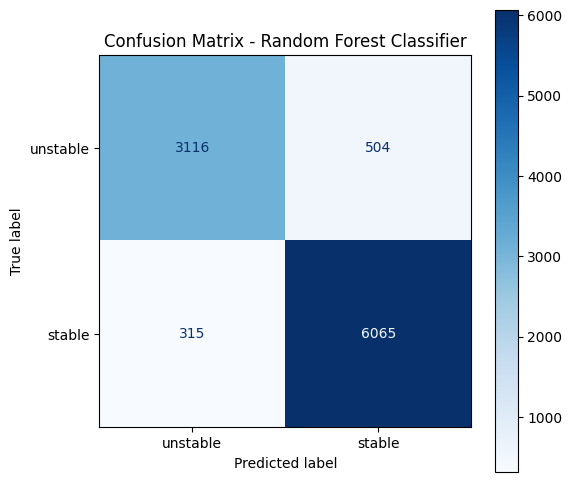


=== Classification Report ===
              precision    recall  f1-score   support

      stable       0.91      0.86      0.88      3620
    unstable       0.92      0.95      0.94      6380

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_class = df['stabf']

# אימון מודל סיווג (יער אקראי) ויצירת תחזיות בשיטת K-Fold
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred_class = cross_val_predict(clf_model, X, y_class, cv=kf)

# יצירת מטריצת בלבול
cm = confusion_matrix(y_class, y_pred_class)

# שרטוט המטריצה
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_class.unique())
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

# הדפסת דוח סיווג מפורט
print("\n=== Classification Report ===")
print(classification_report(y_class, y_pred_class))

### מסקנות ביניים: סעיף 3.1 (מטריצת בלבול)
* **זיהוי שגיאות:** ממטריצת הבלבול עולה כי המודל ייצר 504 שגיאות מסוג False Negative (פספוס של מצב לא-יציב) ו-315 שגיאות מסוג False Positive (התראת שווא).
* **משמעות:** כפי שציינו, שגיאות FN הן הקריטיות ביותר. המודל שלנו הצליח לזהות נכונה את רוב מצבי חוסר היציבות, אך 504 הפספוסים שלו דורשים חקירה מעמיקה כדי להבין באילו תנאים הוא "מסתנוור" וטועה.

### 3.2 ניתוח מבוסס הסתברות (Probability-Based Analysis)
בסעיף זה נשווה את רמת הביטחון (Confidence) של המודל בתחזיות נכונות לעומת תחזיות שגויות.
המטרה היא לאתר "שגיאות בביטחון גבוה" (High-confidence errors) – מקרים שבהם המודל טעה אך היה בטוח מאוד בתשובתו. מקרים אלו מצביעים על אזורי עיוורון של המודל שבהם הוא מזהה תבנית מטעה.

In [9]:
# הפקת ההסתברויות (במקום רק את התוצאה הסופית)
y_probs_cv = cross_val_predict(clf_model, X, y_class, cv=kf, method='predict_proba')

# לקיחת רמת הביטחון של המודל בתחזית שלו (הערך המקסימלי מבין 2 המחלקות)
confidence = np.max(y_probs_cv, axis=1)

# ריכוז הנתונים לטבלה נוחה
prob_df = pd.DataFrame({
    'True_Label': y_class,
    'Predicted_Label': y_pred_class,
    'Confidence': confidence
})

# פיצול לקבוצה של תחזיות נכונות וקבוצה של שגיאות
correct_preds = prob_df[prob_df['True_Label'] == prob_df['Predicted_Label']]
incorrect_preds = prob_df[prob_df['True_Label'] != prob_df['Predicted_Label']]

print("=== Confidence Comparison ===")
print(f"Average confidence for CORRECT predictions: {correct_preds['Confidence'].mean():.2f}")
print(f"Average confidence for INCORRECT predictions: {incorrect_preds['Confidence'].mean():.2f}")

# חיפוש שגיאות קיצון (ביטחון של מעל 80%)
high_conf_errors = incorrect_preds[incorrect_preds['Confidence'] > 0.80]
print(f"\nNumber of HIGH-CONFIDENCE ERRORS (>80% sure, but wrong): {len(high_conf_errors)}")

=== Confidence Comparison ===
Average confidence for CORRECT predictions: 0.83
Average confidence for INCORRECT predictions: 0.60

Number of HIGH-CONFIDENCE ERRORS (>80% sure, but wrong): 11


### מסקנות ביניים: סעיף 3.2 (ניתוח מבוסס הסתברות)
* **רמת ביטחון (Confidence):** המודל מציג רמת ביטחון ממוצעת של 83% עבור תחזיות נכונות, לעומת 60% בלבד עבור תחזיות שגויות.
* **משמעות:** נתון זה מעודד מאוד, שכן הוא מעיד שרוב שגיאות המודל מתרחשות באזורי חוסר ודאות ("מקרי גבול" קרובים ל-50/50), ולא עקב זיהוי תבניות שגויות מובהקות.
* **שגיאות בביטחון גבוה:** נמצאו רק 11 מקרים שבהם המודל טעה למרות רמת ביטחון גבוהה מ-80%. המשמעות היא שהמודל אמין מאוד כשהוא מדווח על רמת ביטחון גבוהה.

### 3.3 שגיאה כפונקציה של הפיצ'רים (Error as a Function of Features)
בסעיף זה נשווה את התפלגות הפיצ'רים בין מקרים שבהם המודל צדק לבין מקרים שבהם טעה.
המטרה היא לזהות "אזורי חולשה" (Subpopulations) שבהם המודל מתקשה לבצע הפרדה ברורה בין המחלקות, ככל הנראה עקב חפיפה (התערבבות) גבוהה של הנתונים באזורים אלו.

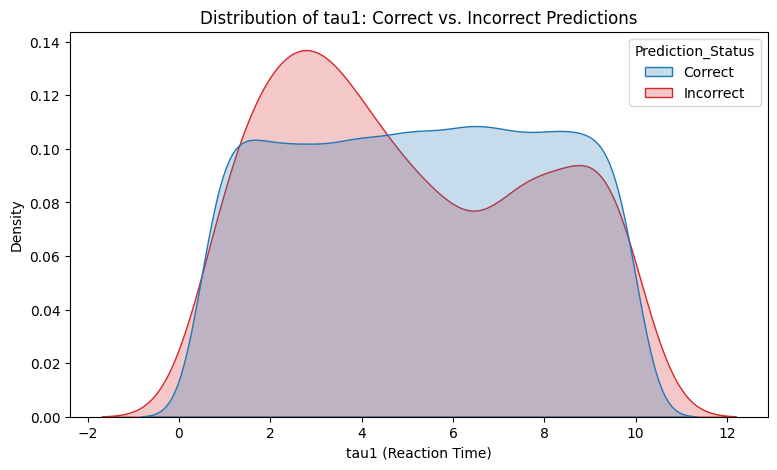

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# יצירת דאטה-פריים זמני לניתוח שמשלב את הפיצ'ר וסטטוס ההצלחה
df_analysis = pd.DataFrame()
df_analysis['tau1'] = df['tau1'] # חילוץ הפיצ'ר מהדאטה המקורי
# הוספת עמודה שאומרת האם המודל צדק או טעה
df_analysis['Prediction_Status'] = (y_class == y_pred_class).replace({True: 'Correct', False: 'Incorrect'})

# שרטוט גרף צפיפות (KDE)
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_analysis, x='tau1', hue='Prediction_Status', common_norm=False, fill=True,
            palette={'Correct': '#1f77b4', 'Incorrect': '#d62728'})
plt.title('Distribution of tau1: Correct vs. Incorrect Predictions')
plt.xlabel('tau1 (Reaction Time)')
plt.ylabel('Density')
plt.show()

### מסקנות ביניים: סעיף 3.3 (שגיאה כפונקציה של הפיצ'רים)
* **אזורי חולשה:** מניתוח התפלגות הפיצ'רים (כדוגמת זמן התגובה `tau1`), ניכר כי התחזיות השגויות (השטח האדום) אינן מפוזרות באופן אחיד, אלא מצטברות בצורה משמעותית באזורי הערכים הנמוכים.
* **משמעות:** המודל מתקשה בעיקר כאשר זמני התגובה של הרשת קצרים מאוד. באזורי פעולה אלו, הדינמיקה של המערכת מהירה ומורכבת יותר, מה שיוצר חפיפה בין התכונות של רשת יציבה לרשת לא-יציבה, ומקשה על המודל לייצר גבול החלטה חד וחלק.

### 3.4 רגישות לסף ההחלטה (Threshold Sensitivity Analysis)
ברירת המחדל של סף ההחלטה במודל סיווג היא 0.5. עם זאת, מכיוון שהשגיאה הקריטית ביותר היא False Negative (פספוס קריסת רשת), נעדיף מודל "רגיש" יותר שמתריע בקלות רבה יותר. בסעיף זה נבחן כיצד שינוי סף ההחלטה (Threshold) משפיע על המדדים השונים (Precision, Recall, F1, MCC), ונציג את עקומת ה-ROC.
המטרה היא למצוא סף נמוך מ-0.5, שיגדיל את ה-Recall (יקטין משמעותית את ה-False Negatives) מבלי לרסק לחלוטין את ה-Precision (יותר מדי התראות שווא).

=== Metrics by Threshold ===


,Threshold,Precision,Recall,F1,MCC
0,0.1,0.673,1.000,0.804,0.310
1,0.2,0.735,1.000,0.847,0.517
2,0.3,0.810,0.996,0.893,0.682
3,0.4,0.866,0.984,0.921,0.770
4,0.5,0.920,0.955,0.937,0.821
5,0.6,0.962,0.899,0.929,0.819
6,0.7,0.990,0.799,0.884,0.755
7,0.8,0.997,0.678,0.807,0.655
8,0.9,1.000,0.485,0.653,0.504


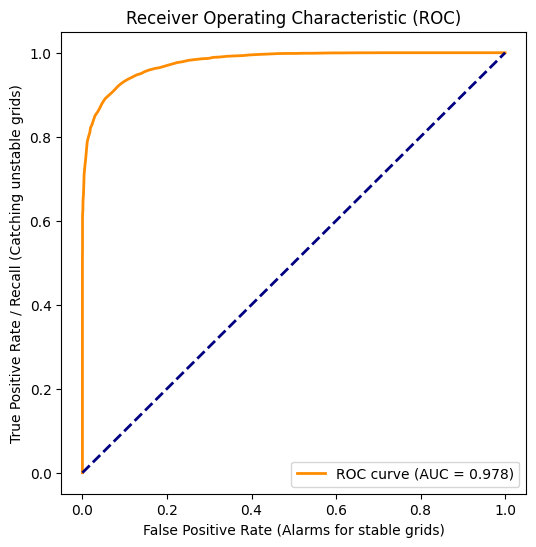

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

# Fit the classifier once to get the class labels in the correct order
# This fit is only to populate clf_model.classes_ for accessing class order
clf_model.fit(X, y_class)

# מציאת האינדקס של המחלקה 'unstable' (הקריטית עבורנו)
unstable_idx = np.where(clf_model.classes_ == 'unstable')[0][0]
y_probs_unstable = y_probs_cv[:, unstable_idx]

thresholds = np.arange(0.1, 1.0, 0.1)
results_thresh = []

# בדיקת המדדים עבור כל סף אפשרי מ-0.1 עד 0.9
for t in thresholds:
    # סיווג לפי הסף: אם ההסתברות גדולה מהסף, נסווג כלא-יציב
    y_pred_t = np.where(y_probs_unstable >= t, 'unstable', 'stable')

    p = precision_score(y_class, y_pred_t, pos_label='unstable')
    r = recall_score(y_class, y_pred_t, pos_label='unstable')
    f1 = f1_score(y_class, y_pred_t, pos_label='unstable')
    mcc = matthews_corrcoef(y_class, y_pred_t)

    results_thresh.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1': f1, 'MCC': mcc})

print("=== Metrics by Threshold ===")
df_thresh = pd.DataFrame(results_thresh)
display(df_thresh.round(3))

# שרטוט עקומת ROC
fpr, tpr, roc_thresholds = roc_curve(y_class, y_probs_unstable, pos_label='unstable')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Alarms for stable grids)')
plt.ylabel('True Positive Rate / Recall (Catching unstable grids)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### מסקנות ביניים: סעיף 3.4 (רגישות לסף ההחלטה)
* **טרייד-אוף ורגישות:** ניתוח המדדים בספים שונים חושף את הטרייד-אוף הקלאסי בין Precision ל-Recall. בסף ברירת המחדל (0.5), המודל מציג תוצאות מאוזנות (F1=0.937).
* **התאמה לבעיה העסקית:** מכיוון שפספוס קריסה (FN) מסוכן בהרבה מהתראת שווא (FP), הורדת סף ההחלטה ל-0.2 או 0.3 היא אסטרטגיה עדיפה. בסף של 0.2, ה-Recall מגיע ל-100%, כלומר המודל מאתר את כל מצבי חוסר היציבות, במחיר סביר של ירידה ב-Precision (0.735).
* **ביצועים כלליים:** עקומת ה-ROC מציגה שטח תחת העקומה (AUC) של 0.978, מה שמעיד על מודל חזק מאוד בעל יכולת הפרדה מצוינת בין המחלקות.

### 3.5 דיון מסכם (Classification Discussion) ופרק 4 (Final Reflection)

**1. היכן המודל נכשל ביותר ולמה?**
המודל מציג ביצועים מעולים הכוללים יכולת הפרדה גבוהה, אך אזור התורפה המרכזי שלו הוא כאשר זמני התגובה של הרשת (tau) קצרים מאוד. הכשלים באזורים אלו נובעים מהדינמיקה המהירה של המערכת, שיוצרת חפיפה משמעותית בתכונות הפיזיקליות בין מצב של רשת יציבה ללא-יציבה, ומקשה על המודל לייצר החלטה חד-משמעית.

**2. אופי השגיאות וסיכונים:**
ניתוח ההסתברויות הראה שכאשר המודל טועה, הוא לרוב שרוי בחוסר ודאות (ביטחון ממוצע של 60%), וישנן רק שגיאות בודדות של "ביטחון מופרז". מבין השגיאות, מצב של False Negative (פספוס קריסת רשת) הוא הקריטי והמסוכן ביותר, עקב פוטנציאל הנזק העצום לחומרה ולצרכנים.

**3. הצעות לשיפור עתידי (Improvements):**
* **כוונון סף החלטה (Threshold Tuning):** הורדת סף ההחלטה ל-0.2 או 0.3 תהפוך את המודל לרגיש יותר ותאפשר "לצוד" כמעט 100% ממקרי חוסר היציבות המסוכנים, תוך השלמה עסקית עם עלייה מתונה בהתראות שווא (False Positives).
* **העשרת נתונים ממוקדת (Data Augmentation):** במקום לשדרג את חומרת החיישנים היקרה כדי להתמודד עם הקצבים המהירים, נבצע איסוף נתונים ממוקד או נייצר סימולציות נוספות שמתרכזות ספציפית במצבים של זמן תגובה קצר (tau נמוך). מתן דאטה רב ואיכותי יותר באזורים אלו יאפשר למודל האנסמבל ללמוד את תבניות הקיצון טוב יותר עם החומרה הקיימת.

**4. תובנות מרכזיות מהתהליך (Insights Gained):**
הניתוח המחיש באופן מעשי את הטרייד-אוף החשוב בין יכולת פירוש (מודל ליניארי פשוט) לבין ביצועי חיזוי ויציבות במקרי קיצון (יער אקראי). מעל לכל, הודגם כיצד מודל למידת מכונה לא יכול להיבחן רק על סמך "אחוזי הצלחה" יבשים, אלא חייב להיות מותאם אקטיבית (דרך בחירת המדדים וסף ההחלטה) לסיכון העסקי וההנדסי הממשי שאיתו המערכת מתמודדת.